In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/josephrasanjana/nail-disease-image-classification-dataset/nail_disease_dataset/test/healthy/dc0ccf0f-02ba-4b50-9f95-ee2ae0e5fe3e.JPG
/kaggle/input/datasets/josephrasanjana/nail-disease-image-classification-dataset/nail_disease_dataset/test/healthy/IMG_20230618_090105.jpg
/kaggle/input/datasets/josephrasanjana/nail-disease-image-classification-dataset/nail_disease_dataset/test/healthy/h92_png_jpg.rf.922d4997328ca5b7a07a9b59074bd7c8.jpg
/kaggle/input/datasets/josephrasanjana/nail-disease-image-classification-dataset/nail_disease_dataset/test/healthy/20230611_093029.jpg
/kaggle/input/datasets/josephrasanjana/nail-disease-image-classification-dataset/nail_disease_dataset/test/healthy/20230611_093137.jpg
/kaggle/input/datasets/josephrasanjana/nail-disease-image-classification-dataset/nail_disease_dataset/test/healthy/IMG-20230617-WA0005.jpg
/kaggle/input/datasets/josephrasanjana/nail-disease-image-classification-dataset/nail_disease_dataset/test/healthy/h23_png_jpg.rf

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt

# GPU'nun aktif olup olmadığını teyit edelim
print("Kullanılabilir GPU'lar:", tf.config.list_physical_devices('GPU'))
print("-" * 30)

# KENDİ KOPYALADIĞIN YOLLARI BURAYA YAPIŞTIR
# Örnek: '/kaggle/input/veri-seti-adi/tırnak_hastalığı_veri küme/train'
train_yolu = '/kaggle/input/datasets/josephrasanjana/nail-disease-image-classification-dataset/nail_disease_dataset/train' 
test_yolu = '/kaggle/input/datasets/josephrasanjana/nail-disease-image-classification-dataset/nail_disease_dataset/test'

# Modelin bizden beklediği standart görüntü boyutu
IMG_SIZE = (224, 224) 
# Görüntüleri belleğe kaçarlı gruplar halinde alacağımız (Standart 32 iyidir)
BATCH_SIZE = 32

print("Eğitim verisi yükleniyor:")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_yolu,
    shuffle=True, # Verileri karıştırıyoruz ki model ezberlemesin
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("\nTest (Doğrulama) verisi yükleniyor:")
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_yolu,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Sınıf isimlerini alıp ekrana yazdıralım
class_names = train_dataset.class_names
print("\nBulunan Sınıflar:", class_names)

2026-05-14 08:28:49.613334: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778747329.650204     672 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778747329.658102     672 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778747329.676942     672 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778747329.676961     672 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778747329.676963     672 computation_placer.cc:177] computation placer alr

Kullanılabilir GPU'lar: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
------------------------------
Eğitim verisi yükleniyor:
Found 1164 files belonging to 3 classes.


I0000 00:00:1778747339.689098     672 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778747339.694288     672 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



Test (Doğrulama) verisi yükleniyor:
Found 299 files belonging to 3 classes.

Bulunan Sınıflar: ['healthy', 'onychomycosis', 'psoriasis']


In [3]:
# 1. Hazır Modeli İndiriyoruz (EfficientNetV2S - Small Versiyon)
# include_top=False: Orijinal 1000 sınıflı başlığı atıp kendi 3 sınıflı başlığımızı takacağız
print("EfficientNetV2S Modeli indiriliyor...")
base_model_s = tf.keras.applications.EfficientNetV2S(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet' 
)

# Hazır modelin daha önceden öğrendiği bilgileri unutmaması için onu donduruyoruz
base_model_s.trainable = False 

# 2. Kendi Sınıflandırıcımızı (Beynin Son Karar Kısmını) Ekliyoruz
inputs = tf.keras.Input(shape=(224, 224, 3))

# Veriyi modele veriyoruz (training=False diyerek BatchNorm katmanlarını sabitliyoruz)
x = base_model_s(inputs, training=False) 

# Görüntüden çıkan karmaşık özellikleri tek boyutlu bir vektöre çeviriyoruz
x = tf.keras.layers.GlobalAveragePooling2D()(x) 

# Modelin aşırı ezberlemesini (overfitting) engellemek için Dropout kullanıyoruz
x = tf.keras.layers.Dropout(0.2)(x) 

# Sonuç katmanımız: 3 sınıfımız olduğu için 3 nöron ve softmax aktivasyonu
outputs = tf.keras.layers.Dense(3, activation='softmax')(x) 

# 3. Giriş ve Çıkışı Birleştirip Nihai Modelimizi Oluşturuyoruz
model_s = tf.keras.Model(inputs, outputs)

# Modeli Derliyoruz (Nasıl öğreneceğini söylüyoruz)
model_s.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("Model başarıyla kuruldu! İşte modelin mimari özeti:")
model_s.summary()

EfficientNetV2S Modeli indiriliyor...
Model başarıyla kuruldu! İşte modelin mimari özeti:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 7, 7, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,335,203 (77.57 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 20,331,360 (77.56 MB)

Model 10 tur boyunca eğitilecek. Antrenman başlıyor...

Epoch 1/10


I0000 00:00:1778747364.853151     746 service.cc:152] XLA service 0x786ac4027db0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778747364.853194     746 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778747364.853200     746 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778747369.166580     746 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-14 08:29:37.485030: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 08:29:37.624567: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 08:29:38.543789: E external/local_xl

 1/37 ━━━━━━━━━━━━━━━━━━━━ 30:02 50s/step - accuracy: 0.4375 - loss: 1.1262

I0000 00:00:1778747394.640450     746 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


36/37 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.5542 - loss: 0.9179

2026-05-14 08:30:08.410849: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 08:30:08.545121: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 08:30:09.366770: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 08:30:09.503685: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 08:30:10.923252: E external/local_xla/xla/stream_

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 840ms/step - accuracy: 0.5575 - loss: 0.9133

2026-05-14 08:30:40.618852: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 08:30:40.753178: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 08:30:41.589993: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 08:30:41.727819: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 08:30:43.190910: E external/local_xla/xla/stream_

37/37 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.5606 - loss: 0.9089 - val_accuracy: 0.7926 - val_loss: 0.5929
Epoch 2/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 128ms/step - accuracy: 0.8263 - loss: 0.4913 - val_accuracy: 0.8528 - val_loss: 0.4671
Epoch 3/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 128ms/step - accuracy: 0.8636 - loss: 0.3974 - val_accuracy: 0.8729 - val_loss: 0.4233
Epoch 4/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 130ms/step - accuracy: 0.8811 - loss: 0.3508 - val_accuracy: 0.8963 - val_loss: 0.3739
Epoch 5/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 129ms/step - accuracy: 0.8810 - loss: 0.3433 - val_accuracy: 0.8997 - val_loss: 0.3569
Epoch 6/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 129ms/step - accuracy: 0.8963 - loss: 0.3049 - val_accuracy: 0.9097 - val_loss: 0.3189
Epoch 7/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 127ms/step - accuracy: 0.8776 - loss: 0.3079 - val_accuracy: 0.9064 - val_loss: 0.3085
Epoch 8/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 126ms/step - accuracy: 0.9116 - loss: 0.2695 - val_accuracy: 0.9097 - val_l

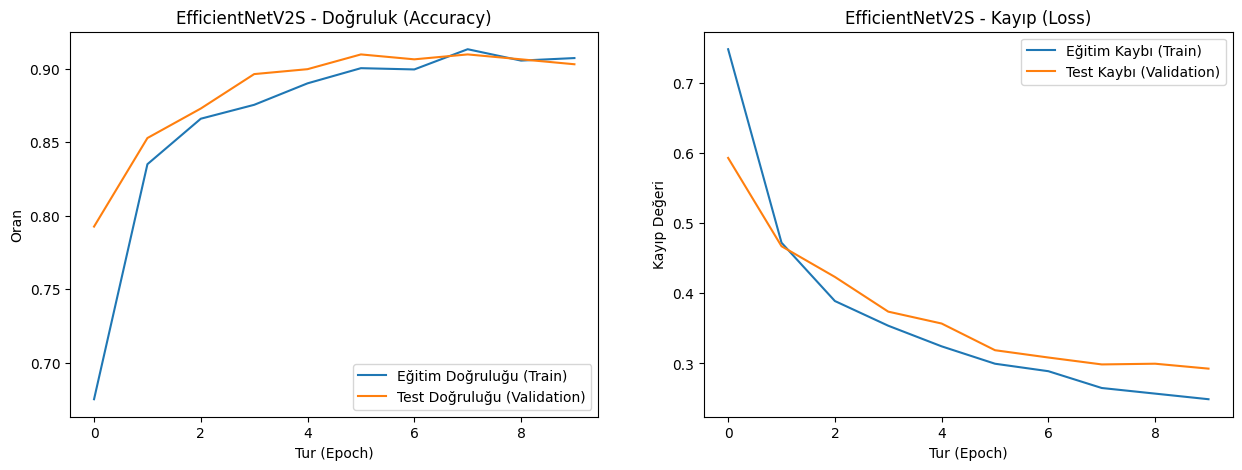


Karmaşıklık Matrisi oluşturuluyor...


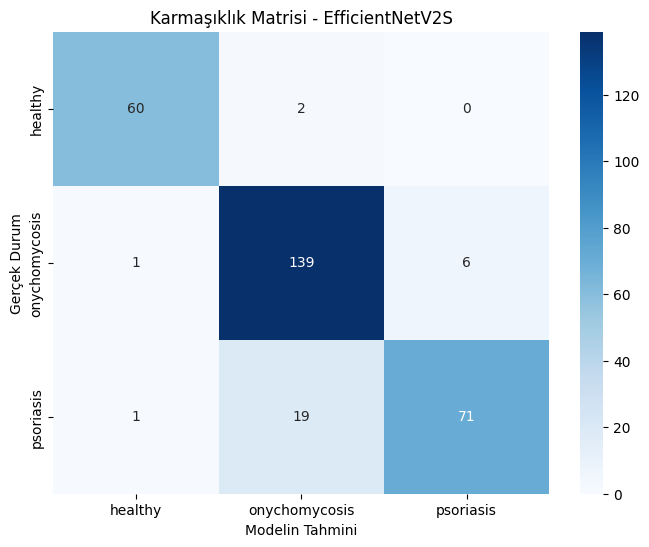


MODEL AND TEST METRICS
Total Params        : 20335203
Trainable Params    : 3843
Non-Trainable Params : 20331360

Test Loss           : 0.292661
Test Accuracy (Keras) : 0.903010
Test Accuracy       : 0.903010
Test Precision      : 0.905507
Test Recall         : 0.903010
Test F1-Score       : 0.901529

Classification Report
               precision    recall  f1-score   support

      healthy       0.97      0.97      0.97        62
onychomycosis       0.87      0.95      0.91       146
    psoriasis       0.92      0.78      0.85        91

     accuracy                           0.90       299
    macro avg       0.92      0.90      0.91       299
 weighted avg       0.91      0.90      0.90       299



In [4]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf # Parametre hesaplamaları için eklendi
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score # Metrikler eklendi

# 1. ADIM: EĞİTİM (TRAINING)
epochs = 10
print(f"Model {epochs} tur boyunca eğitilecek. Antrenman başlıyor...\n")

history_s = model_s.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=epochs
)

print("\nEğitim tamamlandı! Görselleştirmeler hazırlanıyor...")

# 2. ADIM: ACCURACY VE LOSS GRAFİKLERİ
acc = history_s.history['accuracy']
val_acc = history_s.history['val_accuracy']
loss = history_s.history['loss']
val_loss = history_s.history['val_loss']

plt.figure(figsize=(15, 5))

# Doğruluk Grafiği
plt.subplot(1, 2, 1)
plt.plot(acc, label='Eğitim Doğruluğu (Train)')
plt.plot(val_acc, label='Test Doğruluğu (Validation)')
plt.title('EfficientNetV2S - Doğruluk (Accuracy)')
plt.xlabel('Tur (Epoch)')
plt.ylabel('Oran')
plt.legend()

# Kayıp Grafiği
plt.subplot(1, 2, 2)
plt.plot(loss, label='Eğitim Kaybı (Train)')
plt.plot(val_loss, label='Test Kaybı (Validation)')
plt.title('EfficientNetV2S - Kayıp (Loss)')
plt.xlabel('Tur (Epoch)')
plt.ylabel('Kayıp Değeri')
plt.legend()
plt.show()

# 3. ADIM: TAHMİNLER VE KARMAŞIKLIK MATRİSİ (CONFUSION MATRIX)
print("\nKarmaşıklık Matrisi oluşturuluyor...")
y_true = []
y_pred_probs = []

# Test verisi üzerinden tahminleri topluyoruz
for images, labels in test_dataset:
    y_true.extend(labels.numpy())
    preds = model_s.predict(images, verbose=0)
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred = np.argmax(y_pred_probs, axis=1)

# Matris Hesaplama
cm = confusion_matrix(y_true, y_pred)

# Matrisi Görselleştirme
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Karmaşıklık Matrisi - EfficientNetV2S')
plt.xlabel('Modelin Tahmini')
plt.ylabel('Gerçek Durum')
plt.show()

# 4. ADIM: AKADEMİK RAPOR 
print("\nMODEL AND TEST METRICS")
print("=================================================================")

# Parametre sayılarını hesaplama
total_params = model_s.count_params()
trainable_params = sum([tf.keras.backend.count_params(w) for w in model_s.trainable_weights])
non_trainable_params = sum([tf.keras.backend.count_params(w) for w in model_s.non_trainable_weights])

print(f"Total Params        : {total_params}")
print(f"Trainable Params    : {trainable_params}")
print(f"Non-Trainable Params : {non_trainable_params}\n")

# Keras evaluate ile Test Loss ve Test Accuracy (Keras) değerlerini çekme
test_loss, test_acc_keras = model_s.evaluate(test_dataset, verbose=0)

# Sklearn metrikleri ile genel skorları hesaplama
test_acc = accuracy_score(y_true, y_pred)
test_precision = precision_score(y_true, y_pred, average='weighted')
test_recall = recall_score(y_true, y_pred, average='weighted')
test_f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Test Loss           : {test_loss:.6f}")
print(f"Test Accuracy (Keras) : {test_acc_keras:.6f}")
print(f"Test Accuracy       : {test_acc:.6f}")
print(f"Test Precision      : {test_precision:.6f}")
print(f"Test Recall         : {test_recall:.6f}")
print(f"Test F1-Score       : {test_f1:.6f}\n")

print("Classification Report")
print("=================================================================")
print(classification_report(y_true, y_pred, target_names=class_names, digits=2))

In [5]:
# 1. Hazır Modeli İndiriyoruz (EfficientNetV2M - Medium Versiyon)
print("EfficientNetV2M Modeli indiriliyor...")
base_model_m = tf.keras.applications.EfficientNetV2M(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet' 
)

# Hazır modelin bilgilerini donduruyoruz
base_model_m.trainable = False 

# 2. Kendi Sınıflandırıcımızı Ekliyoruz
inputs = tf.keras.Input(shape=(224, 224, 3))

# Veriyi modele veriyoruz
x = base_model_m(inputs, training=False) 

# Özellikleri tek boyutlu vektöre çeviriyoruz
x = tf.keras.layers.GlobalAveragePooling2D()(x) 

# Overfitting engellemek için Dropout
x = tf.keras.layers.Dropout(0.2)(x) 

# Sonuç katmanımız: 3 sınıf
outputs = tf.keras.layers.Dense(3, activation='softmax')(x) 

# 3. Nihai Modelimizi Oluşturuyoruz
model_m = tf.keras.Model(inputs, outputs)

# Modeli Derliyoruz
model_m.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("EfficientNetV2M başarıyla kuruldu! İşte modelin mimari özeti:")
model_m.summary()

EfficientNetV2M Modeli indiriliyor...
214201816/214201816 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
EfficientNetV2M başarıyla kuruldu! İşte modelin mimari özeti:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-m (Functional)   │ (None, 7, 7, 1280)     │    53,150,388 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,154,231 (202.77 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 53,150,388 (202.75 MB)

EfficientNetV2M 10 tur boyunca eğitilecek. Antrenman başlıyor...

Epoch 1/10


2026-05-14 08:38:41.085851: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 08:38:41.223264: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 08:38:42.208786: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 08:38:42.355621: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 08:38:43.921250: E external/local_xla/xla/stream_

36/37 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.4550 - loss: 0.9933

2026-05-14 08:39:25.948971: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 08:39:26.093656: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 08:39:26.986571: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 08:39:27.124652: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 08:39:28.637660: E external/local_xla/xla/stream_

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4588 - loss: 0.9889   

2026-05-14 08:40:11.204552: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 08:40:11.340391: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 08:40:11.473895: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 08:40:12.366023: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 08:40:12.505059: E external/local_xla/xla/stream_

37/37 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.4625 - loss: 0.9848 - val_accuracy: 0.8261 - val_loss: 0.6212
Epoch 2/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 228ms/step - accuracy: 0.7863 - loss: 0.5666 - val_accuracy: 0.8294 - val_loss: 0.5330
Epoch 3/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 232ms/step - accuracy: 0.8032 - loss: 0.4890 - val_accuracy: 0.8361 - val_loss: 0.4999
Epoch 4/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 226ms/step - accuracy: 0.8501 - loss: 0.4263 - val_accuracy: 0.8161 - val_loss: 0.4744
Epoch 5/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 219ms/step - accuracy: 0.8394 - loss: 0.4004 - val_accuracy: 0.8528 - val_loss: 0.4428
Epoch 6/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 218ms/step - accuracy: 0.8536 - loss: 0.3841 - val_accuracy: 0.8629 - val_loss: 0.4266
Epoch 7/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 214ms/step - accuracy: 0.8579 - loss: 0.3613 - val_accuracy: 0.8662 - val_loss: 0.4197
Epoch 8/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 215ms/step - accuracy: 0.8607 - loss: 0.3541 - val_accuracy: 0.8729 - val_l

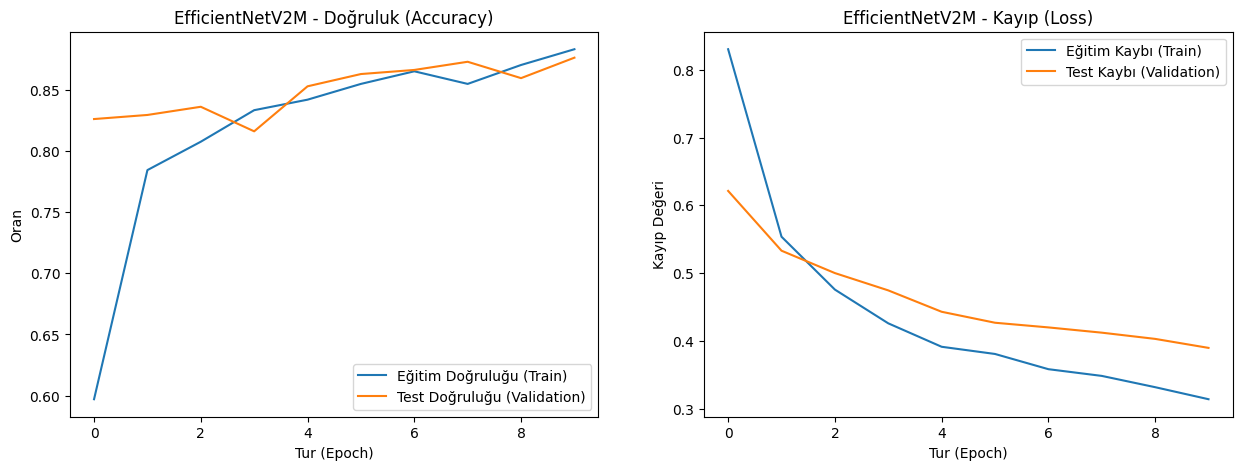


Karmaşıklık Matrisi oluşturuluyor...


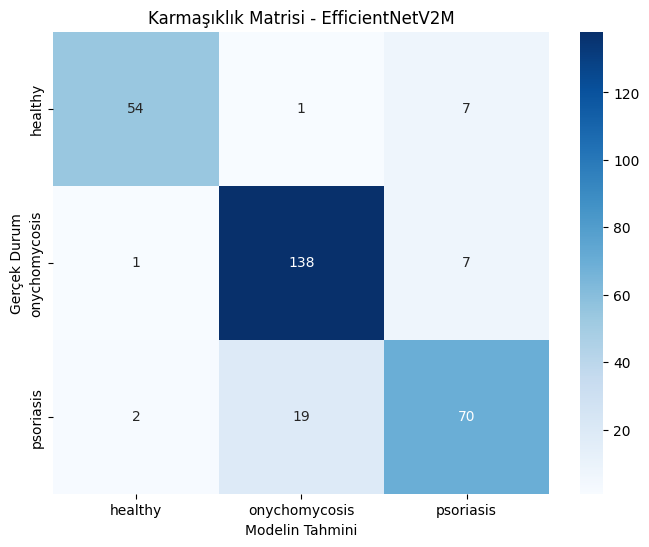


MODEL AND TEST METRICS (EfficientNetV2M)
Total Params        : 53154231
Trainable Params    : 3843
Non-Trainable Params : 53150388

Test Loss           : 0.389508
Test Accuracy (Keras) : 0.876254
Test Accuracy       : 0.876254
Test Precision      : 0.876552
Test Recall         : 0.876254
Test F1-Score       : 0.874988

Classification Report
               precision    recall  f1-score   support

      healthy       0.95      0.87      0.91        62
onychomycosis       0.87      0.95      0.91       146
    psoriasis       0.83      0.77      0.80        91

     accuracy                           0.88       299
    macro avg       0.88      0.86      0.87       299
 weighted avg       0.88      0.88      0.87       299



In [6]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

# 1. ADIM: EĞİTİM (TRAINING)
epochs = 10
print(f"EfficientNetV2M {epochs} tur boyunca eğitilecek. Antrenman başlıyor...\n")

history_m = model_m.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=epochs
)

print("\nEğitim tamamlandı! Görselleştirmeler hazırlanıyor...")

# 2. ADIM: ACCURACY VE LOSS GRAFİKLERİ
acc = history_m.history['accuracy']
val_acc = history_m.history['val_accuracy']
loss = history_m.history['loss']
val_loss = history_m.history['val_loss']

plt.figure(figsize=(15, 5))

# Doğruluk Grafiği
plt.subplot(1, 2, 1)
plt.plot(acc, label='Eğitim Doğruluğu (Train)')
plt.plot(val_acc, label='Test Doğruluğu (Validation)')
plt.title('EfficientNetV2M - Doğruluk (Accuracy)')
plt.xlabel('Tur (Epoch)')
plt.ylabel('Oran')
plt.legend()

# Kayıp Grafiği
plt.subplot(1, 2, 2)
plt.plot(loss, label='Eğitim Kaybı (Train)')
plt.plot(val_loss, label='Test Kaybı (Validation)')
plt.title('EfficientNetV2M - Kayıp (Loss)')
plt.xlabel('Tur (Epoch)')
plt.ylabel('Kayıp Değeri')
plt.legend()
plt.show()

# 3. ADIM: TAHMİNLER VE KARMAŞIKLIK MATRİSİ
print("\nKarmaşıklık Matrisi oluşturuluyor...")
y_true = []
y_pred_probs = []

for images, labels in test_dataset:
    y_true.extend(labels.numpy())
    preds = model_m.predict(images, verbose=0)
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Karmaşıklık Matrisi - EfficientNetV2M')
plt.xlabel('Modelin Tahmini')
plt.ylabel('Gerçek Durum')
plt.show()

# 4. ADIM: AKADEMİK RAPOR VE TEST METRİKLERİ
print("\nMODEL AND TEST METRICS (EfficientNetV2M)")
print("=================================================================")

total_params = model_m.count_params()
trainable_params = sum([tf.keras.backend.count_params(w) for w in model_m.trainable_weights])
non_trainable_params = sum([tf.keras.backend.count_params(w) for w in model_m.non_trainable_weights])

print(f"Total Params        : {total_params}")
print(f"Trainable Params    : {trainable_params}")
print(f"Non-Trainable Params : {non_trainable_params}\n")

test_loss, test_acc_keras = model_m.evaluate(test_dataset, verbose=0)

test_acc = accuracy_score(y_true, y_pred)
test_precision = precision_score(y_true, y_pred, average='weighted')
test_recall = recall_score(y_true, y_pred, average='weighted')
test_f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Test Loss           : {test_loss:.6f}")
print(f"Test Accuracy (Keras) : {test_acc_keras:.6f}")
print(f"Test Accuracy       : {test_acc:.6f}")
print(f"Test Precision      : {test_precision:.6f}")
print(f"Test Recall         : {test_recall:.6f}")
print(f"Test F1-Score       : {test_f1:.6f}\n")

print("Classification Report")
print("=================================================================")
print(classification_report(y_true, y_pred, target_names=class_names, digits=2))

In [7]:
# 1. Hazır Modeli İndiriyoruz (EfficientNetV2L - Large Versiyon)
print("EfficientNetV2L Modeli indiriliyor...")
base_model_l = tf.keras.applications.EfficientNetV2L(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet' 
)

# Hazır modelin bilgilerini donduruyoruz
base_model_l.trainable = False 

# 2. Kendi Sınıflandırıcımızı Ekliyoruz
inputs = tf.keras.Input(shape=(224, 224, 3))

# Veriyi modele veriyoruz
x = base_model_l(inputs, training=False) 

# Özellikleri tek boyutlu vektöre çeviriyoruz
x = tf.keras.layers.GlobalAveragePooling2D()(x) 

# Overfitting engellemek için Dropout
x = tf.keras.layers.Dropout(0.2)(x) 

# Sonuç katmanımız: 3 sınıf
outputs = tf.keras.layers.Dense(3, activation='softmax')(x) 

# 3. Nihai Modelimizi Oluşturuyoruz
model_l = tf.keras.Model(inputs, outputs)

# Modeli Derliyoruz
model_l.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("EfficientNetV2L başarıyla kuruldu! İşte modelin mimari özeti:")
model_l.summary()

EfficientNetV2L Modeli indiriliyor...
473176280/473176280 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step
EfficientNetV2L başarıyla kuruldu! İşte modelin mimari özeti:


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-l (Functional)   │ (None, 7, 7, 1280)     │   117,746,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,750,691 (449.18 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 117,746,848 (449.17 MB)

EfficientNetV2L 10 tur boyunca eğitilecek. Antrenman başlıyor...

Epoch 1/10


2026-05-14 08:45:09.029819: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 08:45:09.179420: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 08:45:10.244169: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 08:45:10.398069: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 08:45:12.099228: E external/local_xla/xla/stream_

36/37 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.5715 - loss: 0.9123

2026-05-14 08:46:17.897058: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 08:46:18.037979: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 08:46:18.921900: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 08:46:19.068771: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 08:46:20.631499: E external/local_xla/xla/stream_

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5742 - loss: 0.9091   

2026-05-14 08:47:21.341495: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 08:47:21.482181: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 08:47:22.353886: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 08:47:22.499203: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 08:47:24.004607: E external/local_xla/xla/stream_

37/37 ━━━━━━━━━━━━━━━━━━━━ 204s 3s/step - accuracy: 0.5768 - loss: 0.9061 - val_accuracy: 0.7659 - val_loss: 0.6712
Epoch 2/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 16s 442ms/step - accuracy: 0.7800 - loss: 0.6012 - val_accuracy: 0.8027 - val_loss: 0.5734
Epoch 3/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 16s 428ms/step - accuracy: 0.8225 - loss: 0.4986 - val_accuracy: 0.8194 - val_loss: 0.5254
Epoch 4/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 15s 409ms/step - accuracy: 0.8450 - loss: 0.4305 - val_accuracy: 0.8127 - val_loss: 0.4996
Epoch 5/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 15s 408ms/step - accuracy: 0.8614 - loss: 0.4133 - val_accuracy: 0.8194 - val_loss: 0.4895
Epoch 6/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 15s 413ms/step - accuracy: 0.8525 - loss: 0.3889 - val_accuracy: 0.8094 - val_loss: 0.5060
Epoch 7/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 15s 418ms/step - accuracy: 0.8432 - loss: 0.3842 - val_accuracy: 0.8294 - val_loss: 0.4652
Epoch 8/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 15s 418ms/step - accuracy: 0.8696 - loss: 0.3483 - val_accuracy: 0.8428 

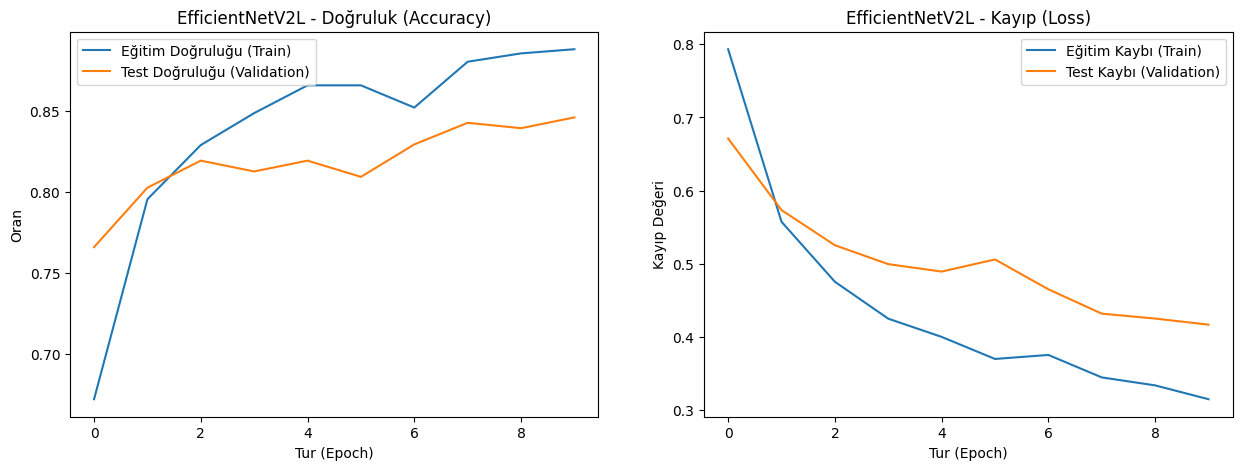


Karmaşıklık Matrisi oluşturuluyor...


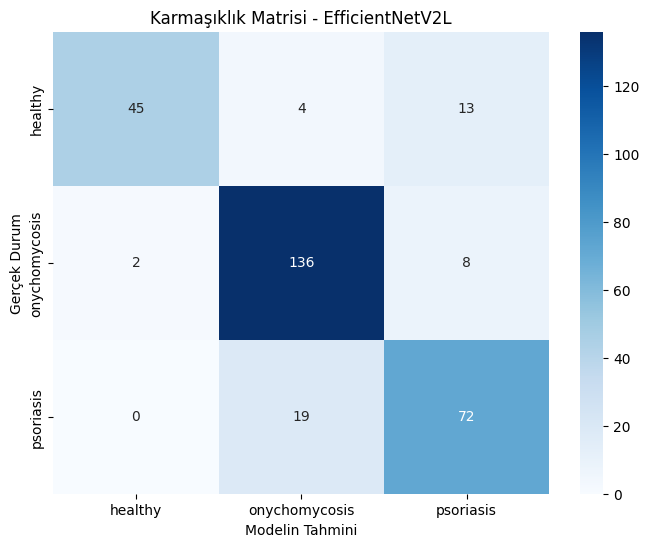


MODEL AND TEST METRICS (EfficientNetV2L)
Total Params        : 117750691
Trainable Params    : 3843
Non-Trainable Params : 117746848

Test Loss           : 0.416962
Test Accuracy (Keras) : 0.846154
Test Accuracy       : 0.846154
Test Precision      : 0.851819
Test Recall         : 0.846154
Test F1-Score       : 0.844861

Classification Report
               precision    recall  f1-score   support

      healthy       0.96      0.73      0.83        62
onychomycosis       0.86      0.93      0.89       146
    psoriasis       0.77      0.79      0.78        91

     accuracy                           0.85       299
    macro avg       0.86      0.82      0.83       299
 weighted avg       0.85      0.85      0.84       299



In [8]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

# 1. ADIM: EĞİTİM (TRAINING)
epochs = 10
print(f"EfficientNetV2L {epochs} tur boyunca eğitilecek. Antrenman başlıyor...\n")

history_l = model_l.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=epochs
)

print("\nEğitim tamamlandı! Görselleştirmeler hazırlanıyor...")

# 2. ADIM: ACCURACY VE LOSS GRAFİKLERİ
acc = history_l.history['accuracy']
val_acc = history_l.history['val_accuracy']
loss = history_l.history['loss']
val_loss = history_l.history['val_loss']

plt.figure(figsize=(15, 5))

# Doğruluk Grafiği
plt.subplot(1, 2, 1)
plt.plot(acc, label='Eğitim Doğruluğu (Train)')
plt.plot(val_acc, label='Test Doğruluğu (Validation)')
plt.title('EfficientNetV2L - Doğruluk (Accuracy)')
plt.xlabel('Tur (Epoch)')
plt.ylabel('Oran')
plt.legend()

# Kayıp Grafiği
plt.subplot(1, 2, 2)
plt.plot(loss, label='Eğitim Kaybı (Train)')
plt.plot(val_loss, label='Test Kaybı (Validation)')
plt.title('EfficientNetV2L - Kayıp (Loss)')
plt.xlabel('Tur (Epoch)')
plt.ylabel('Kayıp Değeri')
plt.legend()
plt.show()

# 3. ADIM: TAHMİNLER VE KARMAŞIKLIK MATRİSİ
print("\nKarmaşıklık Matrisi oluşturuluyor...")
y_true = []
y_pred_probs = []

for images, labels in test_dataset:
    y_true.extend(labels.numpy())
    preds = model_l.predict(images, verbose=0)
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Karmaşıklık Matrisi - EfficientNetV2L')
plt.xlabel('Modelin Tahmini')
plt.ylabel('Gerçek Durum')
plt.show()

# 4. ADIM: AKADEMİK RAPOR VE TEST METRİKLERİ
print("\nMODEL AND TEST METRICS (EfficientNetV2L)")
print("=================================================================")

total_params = model_l.count_params()
trainable_params = sum([tf.keras.backend.count_params(w) for w in model_l.trainable_weights])
non_trainable_params = sum([tf.keras.backend.count_params(w) for w in model_l.non_trainable_weights])

print(f"Total Params        : {total_params}")
print(f"Trainable Params    : {trainable_params}")
print(f"Non-Trainable Params : {non_trainable_params}\n")

test_loss, test_acc_keras = model_l.evaluate(test_dataset, verbose=0)

test_acc = accuracy_score(y_true, y_pred)
test_precision = precision_score(y_true, y_pred, average='weighted')
test_recall = recall_score(y_true, y_pred, average='weighted')
test_f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Test Loss           : {test_loss:.6f}")
print(f"Test Accuracy (Keras) : {test_acc_keras:.6f}")
print(f"Test Accuracy       : {test_acc:.6f}")
print(f"Test Precision      : {test_precision:.6f}")
print(f"Test Recall         : {test_recall:.6f}")
print(f"Test F1-Score       : {test_f1:.6f}\n")

print("Classification Report")
print("=================================================================")
print(classification_report(y_true, y_pred, target_names=class_names, digits=2))